In [ ]:
import pandas as pd

df = pd.read_csv("data/data_ecommerce.csv")
df.info()
df.isnull().sum()


<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            47505 non-null  float64
 1   Gender                         50000 non-null  str    
 2   Country                        50000 non-null  str    
 3   City                           50000 non-null  str    
 4   Membership_Years               50000 non-null  float64
 5   Login_Frequency                50000 non-null  float64
 6   Session_Duration_Avg           46601 non-null  float64
 7   Pages_Per_Session              47000 non-null  float64
 8   Cart_Abandonment_Rate          50000 non-null  float64
 9   Wishlist_Items                 46000 non-null  float64
 10  Total_Purchases                50000 non-null  float64
 11  Average_Order_Value            50000 non-null  float64
 12  Days_Since_Last_Purchase       47000 non-null  float64
 1

Age                              2495
Gender                              0
Country                             0
City                                0
Membership_Years                    0
Login_Frequency                     0
Session_Duration_Avg             3399
Pages_Per_Session                3000
Cart_Abandonment_Rate               0
Wishlist_Items                   4000
Total_Purchases                     0
Average_Order_Value                 0
Days_Since_Last_Purchase         3000
Discount_Usage_Rate              3500
Returns_Rate                     4491
Email_Open_Rate                  2528
Customer_Service_Calls            168
Product_Reviews_Written          3500
Social_Media_Engagement_Score    6000
Mobile_App_Usage                 5000
Payment_Method_Diversity         2500
Lifetime_Value                      0
Credit_Balance                   5500
Churned                             0
Signup_Quarter                      0
dtype: int64

In [2]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df.isnull().sum()

Age                                 0
Gender                              0
Country                             0
City                                0
Membership_Years                    0
Login_Frequency                     0
Session_Duration_Avg             3399
Pages_Per_Session                3000
Cart_Abandonment_Rate               0
Wishlist_Items                   4000
Total_Purchases                     0
Average_Order_Value                 0
Days_Since_Last_Purchase         3000
Discount_Usage_Rate              3500
Returns_Rate                     4491
Email_Open_Rate                  2528
Customer_Service_Calls            168
Product_Reviews_Written          3500
Social_Media_Engagement_Score    6000
Mobile_App_Usage                 5000
Payment_Method_Diversity         2500
Lifetime_Value                      0
Credit_Balance                   5500
Churned                             0
Signup_Quarter                      0
dtype: int64

In [3]:
cols = [
    'Session_Duration_Avg',
    'Pages_Per_Session',
    'Wishlist_Items',
    'Days_Since_Last_Purchase',
    'Discount_Usage_Rate',
    'Returns_Rate',
    'Email_Open_Rate',
    'Customer_Service_Calls',
    'Product_Reviews_Written',
    'Social_Media_Engagement_Score',
    'Mobile_App_Usage',
    'Payment_Method_Diversity',
    'Credit_Balance'
]

for col in cols:
    df[col] = df[col].fillna(df[col].median())

df.isnull().sum()

Age                              0
Gender                           0
Country                          0
City                             0
Membership_Years                 0
Login_Frequency                  0
Session_Duration_Avg             0
Pages_Per_Session                0
Cart_Abandonment_Rate            0
Wishlist_Items                   0
Total_Purchases                  0
Average_Order_Value              0
Days_Since_Last_Purchase         0
Discount_Usage_Rate              0
Returns_Rate                     0
Email_Open_Rate                  0
Customer_Service_Calls           0
Product_Reviews_Written          0
Social_Media_Engagement_Score    0
Mobile_App_Usage                 0
Payment_Method_Diversity         0
Lifetime_Value                   0
Credit_Balance                   0
Churned                          0
Signup_Quarter                   0
dtype: int64

In [4]:
df[['Discount_Usage_Rate','Returns_Rate','Email_Open_Rate']].describe()

,Discount_Usage_Rate,Returns_Rate,Email_Open_Rate
count,50000.000000,50000.000000,50000.000000
mean,41.871661,6.565861,20.875388
std,20.617080,5.872081,13.890225
min,0.240000,0.000000,0.000000
25%,26.500000,3.100000,10.500000
50%,40.200000,5.400000,19.700000
75%,55.560000,8.600000,29.700000
max,116.640000,99.615734,91.700000


In [5]:
df = df[(df['Age'] > 15) & (df['Age'] < 80)]

<Axes: >

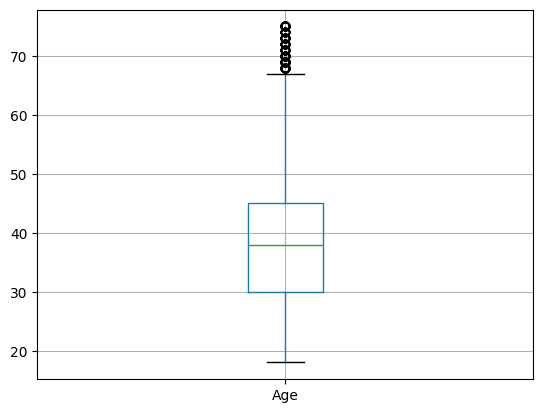

In [6]:
df.boxplot(column='Age')

In [7]:
df[['Session_Duration_Avg', 'Pages_Per_Session', 'Credit_Balance']].describe()

,Session_Duration_Avg,Pages_Per_Session,Credit_Balance
count,49950.000000,49950.000000,49950.000000
mean,27.602286,8.718322,1958.685526
std,10.496613,3.663817,1155.830663
min,1.000000,1.000000,0.000000
25%,20.200000,6.200000,1164.000000
50%,26.800000,8.400000,1896.000000
75%,34.000000,11.000000,2664.000000
max,75.600000,24.100000,7197.000000


In [8]:
df['Gender'].unique()
df['Country'].unique()
df['Churned'].unique()

array([0, 1])

In [9]:
df['Gender'] = df['Gender'].str.strip().str.title()

In [10]:
df['Gender'].unique()
df['Country'].unique()
df['Churned'].unique()

array([0, 1])

In [11]:
df['Churned'].value_counts(normalize=True)

Churned
0    0.711131
1    0.288869
Name: proportion, dtype: float64

In [12]:
df['Activity_Level'] = df['Login_Frequency'] * df['Session_Duration_Avg']

In [13]:
df['Engagement_Score'] = (
    df['Pages_Per_Session'] +
    df['Wishlist_Items'] +
    df['Product_Reviews_Written']
)

## EDA

In [14]:
df.groupby('Churned')[['Discount_Usage_Rate','Social_Media_Engagement_Score']].mean()

,Discount_Usage_Rate,Social_Media_Engagement_Score
Churned,,
0,42.849102,31.365913
1,39.474659,23.716966


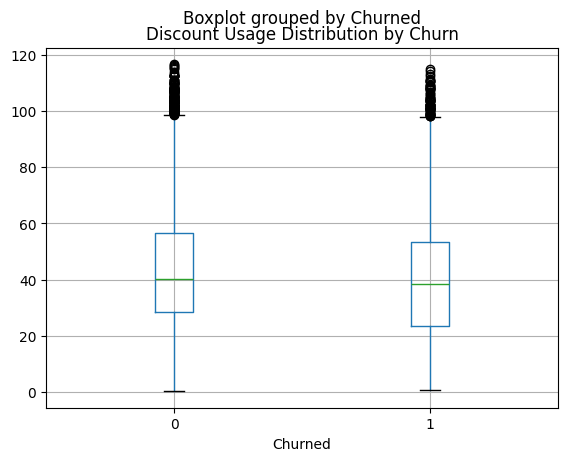

In [15]:
import matplotlib.pyplot as plt

df.boxplot(column='Discount_Usage_Rate', by='Churned')
plt.title("Discount Usage Distribution by Churn")
plt.show()

## Customers who remain active tend to have higher discount usage rates, suggesting that promotional strategies may help improve customer retention. In contrast, customers with lower social media engagement scores are significantly more likely to churn, indicating that customer interaction and engagement play a crucial role in retaining users.

In [16]:
df.groupby('Churned').mean(numeric_only=True)

,Age,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Activity_Level,Engagement_Score
Churned,,,,,,,,,,,,,,,,,,,,,
0,38.500577,2.984596,12.642296,29.071361,9.242839,54.194098,4.644408,13.827617,118.378202,26.538048,...,22.791743,5.184708,3.044678,31.365913,20.499688,2.332958,1446.772507,2067.649447,419.922953,16.931925
1,35.989396,2.982698,9.123016,23.985751,7.427077,64.176610,3.364266,11.351521,134.758803,35.993763,...,16.169977,6.896666,2.176727,23.716966,16.332975,2.344307,1425.381937,1690.440502,271.587504,12.968071


## Customer churn cenderung memiliki aktivitas yang lebih rendah, ditandai dengan frekuensi login yang lebih sedikit, engagement yang rendah, dan waktu yang lebih lama sejak pembelian terakhir. Selain itu, tingginya tingkat cart abandonment dan interaksi dengan customer service juga menunjukkan adanya potensi ketidakpuasan pengguna.

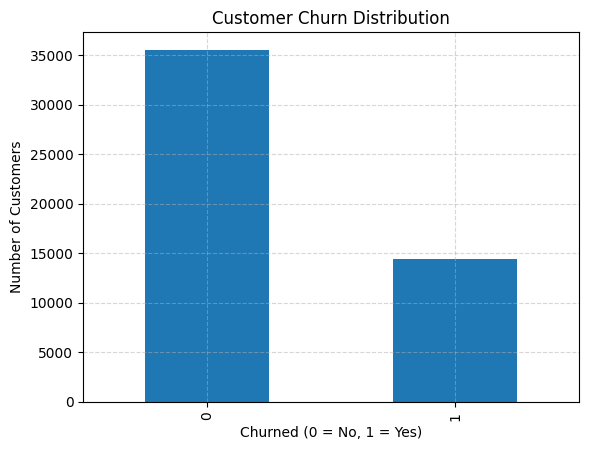

In [17]:
import matplotlib.pyplot as plt

df['Churned'].value_counts().plot(kind='bar')
plt.title("Customer Churn Distribution")
plt.xlabel("Churned (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

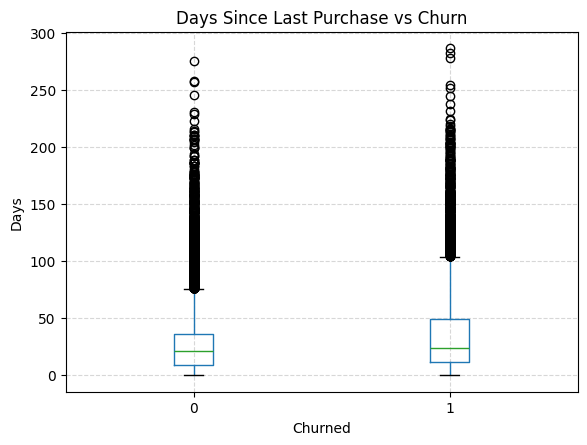

In [18]:
df.boxplot(column='Days_Since_Last_Purchase', by='Churned')
plt.title("Days Since Last Purchase vs Churn")
plt.suptitle("")
plt.xlabel("Churned")
plt.ylabel("Days")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

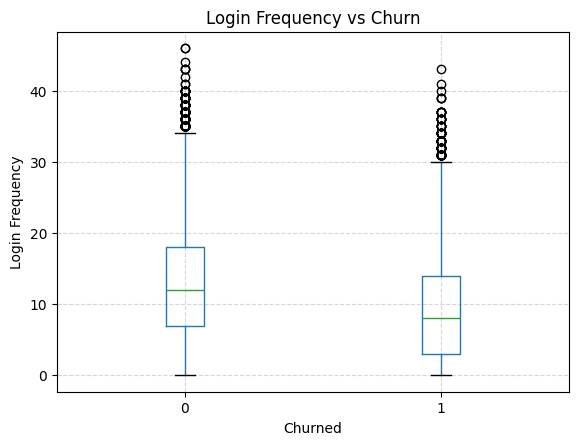

In [19]:
df.boxplot(column='Login_Frequency', by='Churned')
plt.title("Login Frequency vs Churn")
plt.suptitle("")
plt.xlabel("Churned")
plt.ylabel("Login Frequency")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

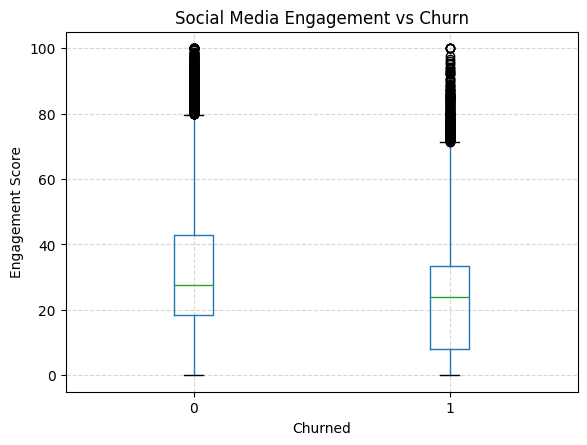

In [20]:
df.boxplot(column='Social_Media_Engagement_Score', by='Churned')
plt.title("Social Media Engagement vs Churn")
plt.suptitle("")
plt.xlabel("Churned")
plt.ylabel("Engagement Score")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

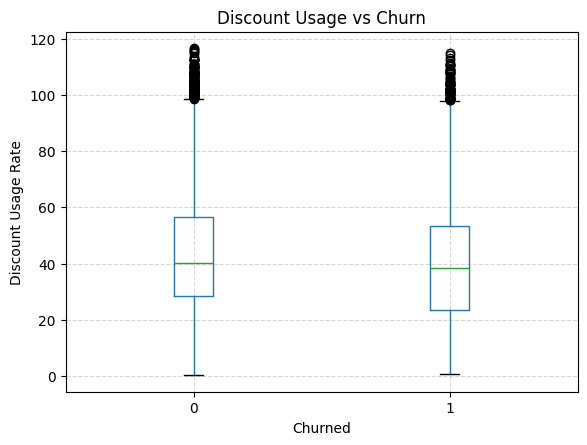

In [21]:
df.boxplot(column='Discount_Usage_Rate', by='Churned')
plt.title("Discount Usage vs Churn")
plt.suptitle("")
plt.xlabel("Churned")
plt.ylabel("Discount Usage Rate")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Customer churn is primarily driven by inactivity, as shown by a significantly higher number of days since the last purchase. Additionally, lower login frequency indicates reduced platform engagement, which further increases churn risk. Social media engagement also plays a role, where less interactive users are more likely to leave.